In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import math
from table_generator import aggregate_across_seeds, load_results_dataframe, flatten_config, diagnose_grouping_conflicts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
wandb_username = "bioshape-lab"  # W&B username/entity
wandb_project = "ogbench"  # W&B project name
csv_filename = "final_results_test.csv"  # Output CSV filename

df = load_results_dataframe(
    wandb_username,
    wandb_project,
    csv_filename=csv_filename,
    force_load=False,
    save_csv=True,
)


aggregated_df = aggregate_across_seeds(
    df,
    seed_cols=None,                 # auto-detects
    metric_prefix="summary.",
    output_filename="aggregated_results.csv",
)

print(aggregated_df.shape)
aggregated_df.head()

▶ Loaded existing CSV file: final_results_test.csv
▶ DataFrame shape: (1517, 254)

▶ Column names (254 total):
--------------------------------------------------------------------------------
  1. run_id
  2. run_name
  3. state
  4. summary.AvgTime/train_batch_mean
  5. summary.AvgTime/train_batch_std
  6. summary.AvgTime/train_epoch_mean
  7. summary.AvgTime/train_epoch_std
  8. summary.AvgTime/val_batch_mean
  9. summary.AvgTime/val_batch_std
 10. summary.AvgTime/val_epoch_mean
 11. summary.AvgTime/val_epoch_std
 12. summary._runtime
 13. summary._step
 14. summary._timestamp
 15. summary.best_test/accuracy
 16. summary.best_test/auroc
 17. summary.best_test/f1_macro
 18. summary.best_test/f1_weighted
 19. summary.best_test/loss
 20. summary.best_test/precision
 21. summary.best_test/recall
 22. summary.best_train/accuracy
 23. summary.best_train/auroc
 24. summary.best_train/f1_macro
 25. summary.best_train/f1_weighted
 26. summary.best_train/loss
 27. summary.best_train/precision


/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated = aggregated.reset_index()
/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated = aggregated.reset_index()
/home/lcornelis/code/bgbench/tutorials/table_generator.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.dataset_loss.class_weights,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,...,summary.val/balanced_accuracy_count,summary.hyperparams/elastic_net__C,summary.hyperparams/elastic_net__C_std,summary.hyperparams/elastic_net__C_count,summary.hyperparams/elastic_net__l1_ratio,summary.hyperparams/elastic_net__l1_ratio_std,summary.hyperparams/elastic_net__l1_ratio_count,summary.val/pr_auc,summary.val/pr_auc_std,summary.val/pr_auc_count
0,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
1,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
2,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
3,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
4,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0


In [5]:
sns.set(style="whitegrid")

# ------------------------------------------------------------------
# Load aggregated results
# ------------------------------------------------------------------
df = pd.read_csv("aggregated_results.csv")

# Columns of interest
cols = [
    "model.model_name",
    "dataset.loader.parameters.node_sample_ratio",
    "dataset.loader.parameters.data_name",
    "dataset.loader.parameters.method",
    "summary.test/accuracy",
    "summary.test/accuracy_std",
    "dataset.parameters.num_classes",  # For random chance calculation
    "dataset.parameters.class_weights",  # For random chance calculation
]

# Keep only columns that actually exist
cols = [c for c in cols if c in df.columns]
df = df[cols].copy()

# ------------------------------------------------------------------
# Decode the serialized strings like "__val__:'sagn'" -> "sagn"
# ------------------------------------------------------------------
def decode_val(x):
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

for c in cols:
    df[c] = df[c].apply(decode_val)

# Rename to shorter names
df = df.rename(
    columns={
        "model.model_name": "model_name",
        "dataset.loader.parameters.node_sample_ratio": "node_sample_ratio",
        "dataset.loader.parameters.data_name": "data_name",
        "dataset.loader.parameters.method": "method",
        "summary.test/accuracy": "test_acc",
        "summary.test/accuracy_std": "test_acc_std",
    }
)

# Ensure numeric dtype
df["node_sample_ratio"] = pd.to_numeric(df["node_sample_ratio"], errors="coerce")
df["test_acc"]          = pd.to_numeric(df["test_acc"], errors="coerce")
df["test_acc_std"]      = pd.to_numeric(df["test_acc_std"], errors="coerce")

# ------------------------------------------------------------------
# Calculate random chance baselines per dataset by loading actual data
# ------------------------------------------------------------------
import os
from huggingface_hub import hf_hub_download

def load_dataset_targets(data_name, revision="9f052d330ce130408a2c7c347b2ed197154da7c8"):
    """
    Load target labels from dataset parquet file and compute class distribution.
    
    Args:
        data_name: Name of the dataset (e.g., "motrpac", "parkinsons", "addneuromed")
        revision: HuggingFace dataset revision (default from config)
    
    Returns:
        tuple: (targets array, class_counts dict, random_chance float)
    """
    # Check for local temp_data first
    local_data_dir = 'temp_data'
    target_filename = f'{data_name}_targets.parquet'
    local_targets_file = os.path.join(local_data_dir, data_name, target_filename)
    
    if os.path.exists(local_targets_file):
        targets_df = pd.read_parquet(local_targets_file)
    else:
        # Download from HuggingFace
        try:
            hf_repo_id = 'geometric-intelligence/bgbench'
            targets_file = hf_hub_download(
                repo_id=hf_repo_id,
                repo_type='dataset',
                revision=revision,
                filename=target_filename,
            )
            targets_df = pd.read_parquet(targets_file)
        except Exception as e:
            print(f"Warning: Could not load targets for {data_name}: {e}")
            return None, None, None
    
    targets = targets_df['target'].values
    
    # Count class distribution
    unique_classes, counts = np.unique(targets, return_counts=True)
    class_counts = dict(zip(unique_classes, counts))
    
    # Calculate proportions
    proportions = counts / len(targets)
    
    # Random chance = accuracy of always predicting majority class
    # This is the "majority class baseline" - if you always predict the most common class,
    # your accuracy will be the proportion of that class in the dataset.
    # Example: If 70% are class 0 and 30% are class 1, always predicting class 0 gives 70% accuracy.
    random_chance = proportions.max()
    
    # Sanity check: verify the calculation
    # The sum of proportions should be 1.0, and random_chance should be between 1/num_classes and 1.0
    assert abs(proportions.sum() - 1.0) < 1e-10, f"Proportions don't sum to 1: {proportions.sum()}"
    assert 1.0 / len(unique_classes) <= random_chance <= 1.0, \
        f"Random chance {random_chance} should be between {1.0/len(unique_classes)} and 1.0"
    
    return targets, class_counts, random_chance

def calculate_random_chance_from_data(data_name):
    """
    Calculate random chance accuracy by loading actual dataset targets.
    
    Args:
        data_name: Name of the dataset
    
    Returns:
        Random chance accuracy (float) or None if cannot be computed
    """
    try:
        # Try to get revision from the dataframe if available
        sub_df = df[df["data_name"] == data_name]
        revisions = sub_df.get("dataset.loader.parameters.revision", pd.Series()).dropna()
        revision = revisions.iloc[0] if len(revisions) > 0 else "9f052d330ce130408a2c7c347b2ed197154da7c8"
        
        targets, class_counts, random_chance = load_dataset_targets(data_name, revision)
        
        if random_chance is not None:
            print(f"Random chance for {data_name}: {random_chance:.4f}")
            if class_counts:
                print(f"  Class distribution: {class_counts}")
            return random_chance
    except Exception as e:
        print(f"Error loading targets for {data_name}: {e}")
    
    return None

# Calculate random chance for each dataset by loading actual data
random_chance_by_dataset = {}
for data_name in df["data_name"].dropna().unique():
    random_chance = calculate_random_chance_from_data(data_name)
    if random_chance is not None:
        random_chance_by_dataset[data_name] = random_chance
    else:
        # Fallback: try to use num_classes from dataframe
        sub_df = df[df["data_name"] == data_name]
        num_classes = sub_df.get("dataset.parameters.num_classes", pd.Series()).dropna()
        if len(num_classes) > 0:
            n_classes = int(num_classes.iloc[0])
            random_chance = 1.0 / n_classes
            random_chance_by_dataset[data_name] = random_chance
            print(f"Random chance for {data_name}: {random_chance:.4f} (fallback: balanced, num_classes={n_classes})")
        else:
            # Final fallback: assume binary
            random_chance_by_dataset[data_name] = 0.5
            print(f"Random chance for {data_name}: 0.5000 (fallback: assumed binary)")

# ------------------------------------------------------------------
# Optional: collapse any accidental duplicates per (data, model, method, ratio)
# ------------------------------------------------------------------
group_cols = ["data_name", "model_name", "method", "node_sample_ratio"]
agg_df = (
    df.groupby(group_cols, as_index=False)
      .agg(
          test_acc     = ("test_acc", "mean"),
          test_acc_std = ("test_acc_std", "mean"),
      )
)

Random chance for motrpac: 0.5734
  Class distribution: {0: 279, 1: 375}
Random chance for addneuromed: 0.3994
  Class distribution: {0: 284, 1: 238, 2: 189}
Random chance for parkinsons: 0.6206
  Class distribution: {0: 332, 1: 203}


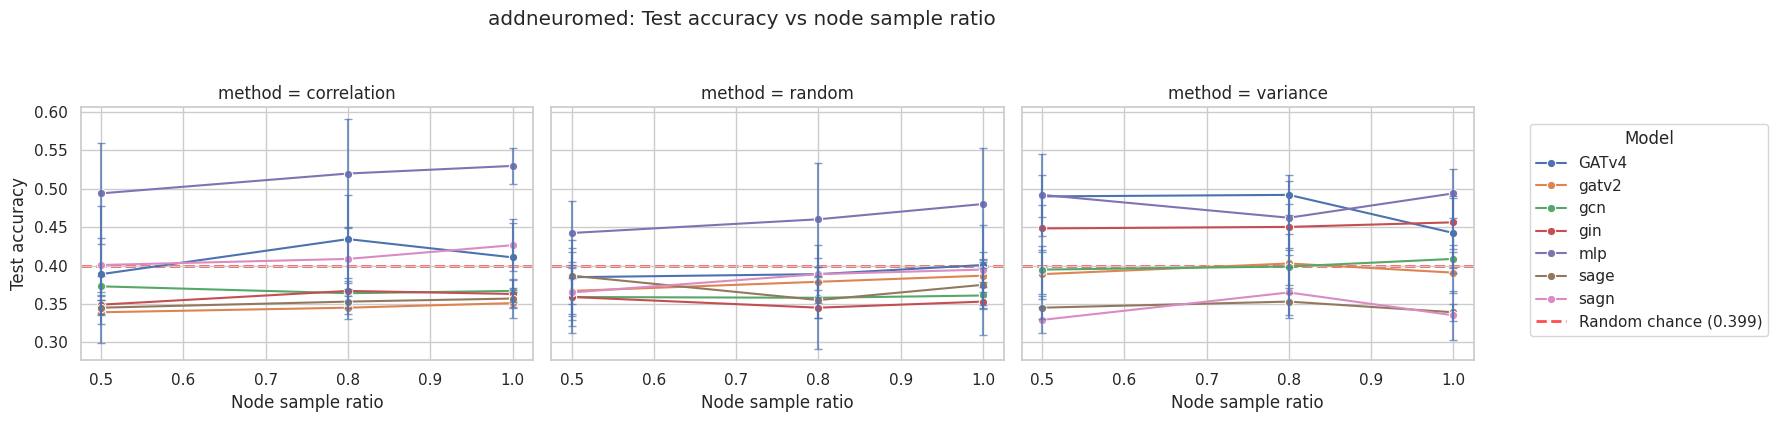

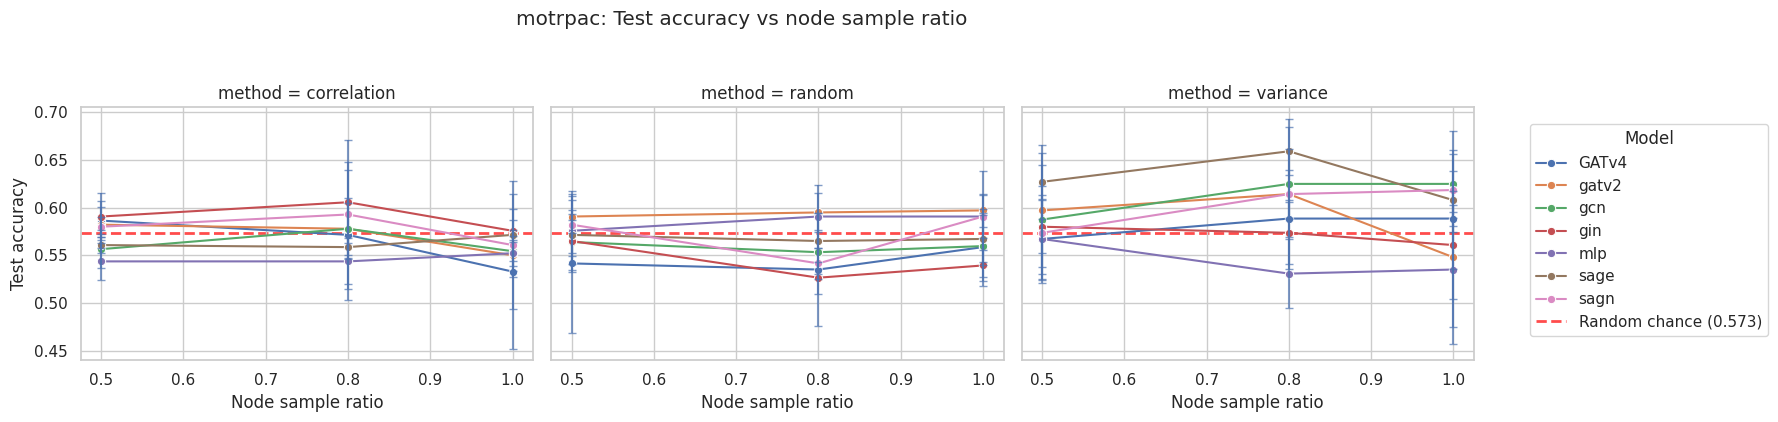

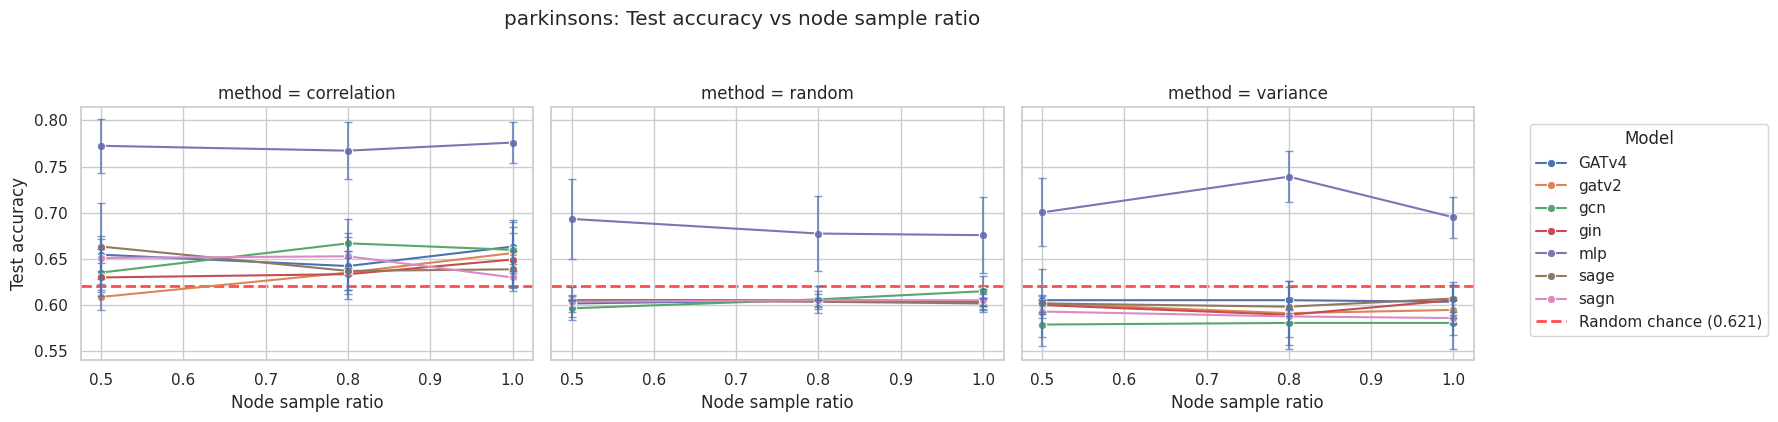

In [6]:
methods = ["correlation", "random", "variance"]

for data_name in sorted(agg_df["data_name"].dropna().unique()):
    sub_data = agg_df[agg_df["data_name"] == data_name].copy()
    if sub_data.empty:
        continue

    # Get random chance baseline for this dataset
    random_chance = random_chance_by_dataset.get(data_name, 0.5)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{data_name}: Test accuracy vs node sample ratio", y=1.05)

    for i, method in enumerate(methods):
        ax = axes[i]
        sub_m = sub_data[sub_data["method"] == method].copy()
        if sub_m.empty:
            ax.set_title(f"{method} (no data)")
            ax.axis("off")
            continue

        # Sort for nicer lines
        sub_m = sub_m.sort_values(["model_name", "node_sample_ratio"])

        # Line per model
        sns.lineplot(
            data=sub_m,
            x="node_sample_ratio",
            y="test_acc",
            hue="model_name",
            marker="o",
            ax=ax,
        )

        # Error bars per (model, ratio)
        for (model_name), grp in sub_m.groupby("model_name"):
            ax.errorbar(
                grp["node_sample_ratio"],
                grp["test_acc"],
                yerr=grp["test_acc_std"],
                fmt="none",
                capsize=3,
                alpha=0.7,
            )

        # Add random chance baseline (without label - we'll add it to legend manually)
        xlim = ax.get_xlim()
        ax.axhline(
            y=random_chance,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            zorder=0,  # Draw behind other elements
        )
        ax.set_xlim(xlim)

        ax.set_title(f"method = {method}")
        ax.set_xlabel("Node sample ratio")
        if i == 0:
            ax.set_ylabel("Test accuracy")
        else:
            ax.set_ylabel("")
        
        # Remove individual plot legends - we'll add one shared legend at the end
        if ax.legend_:
            ax.legend_.remove()

    # Remove legends from all axes first, then collect handles/labels from first axis
    for ax in axes:
        if ax.legend_:
            ax.legend_.remove()
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Filter out any random chance lines that might have been included (shouldn't be, but just in case)
    filtered_handles = []
    filtered_labels = []
    for h, l in zip(handles, labels):
        # Skip if it looks like a random chance line (red dashed line)
        if hasattr(h, 'get_color') and hasattr(h, 'get_linestyle'):
            if h.get_color() == 'red' and h.get_linestyle() == '--':
                continue
        filtered_handles.append(h)
        filtered_labels.append(l)
    
    handles, labels = filtered_handles, filtered_labels
    
    # Add random chance baseline to legend (only once)
    from matplotlib.lines import Line2D
    random_line = Line2D([0], [0], color="red", linestyle="--", linewidth=2, alpha=0.7)
    handles.append(random_line)
    labels.append(f"Random chance ({random_chance:.3f})")
    
    # Put single legend outside on the right
    fig.legend(handles, labels, title="Model", bbox_to_anchor=(1.02, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()

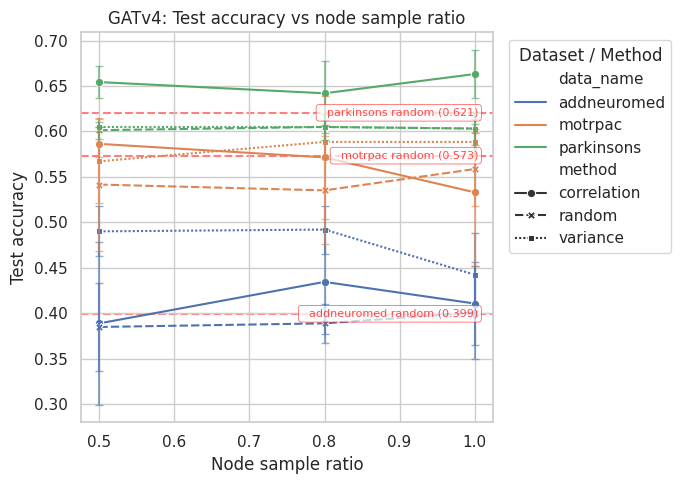

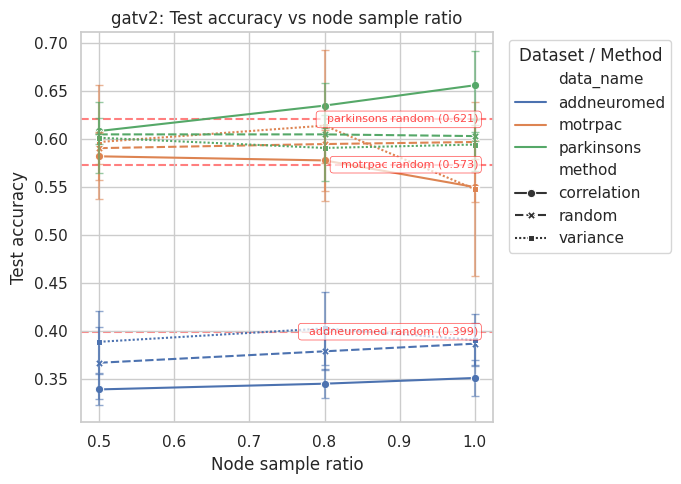

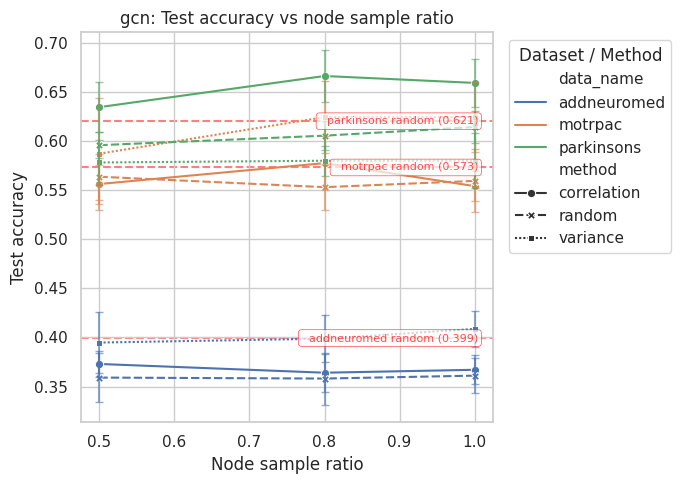

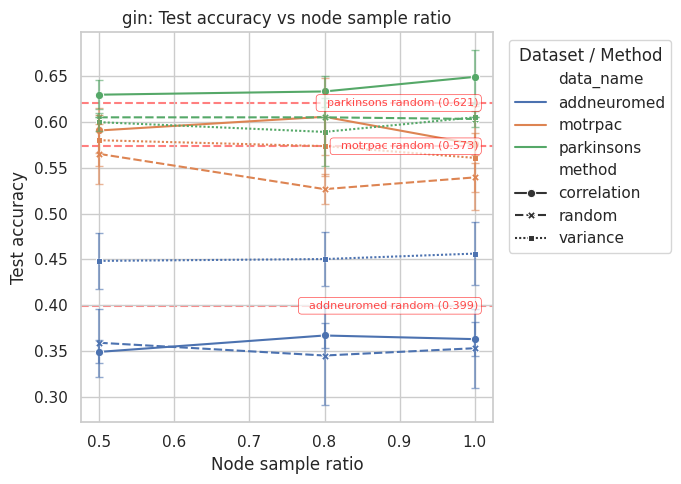

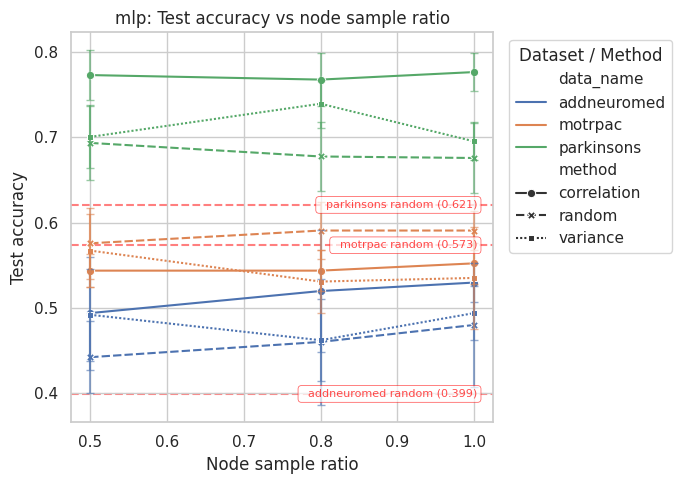

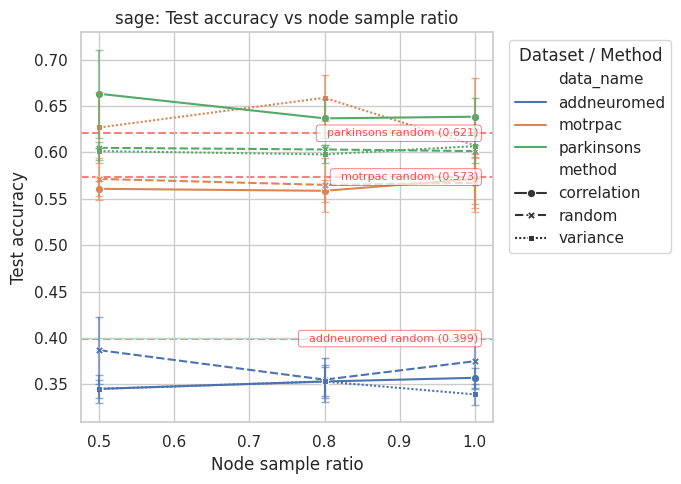

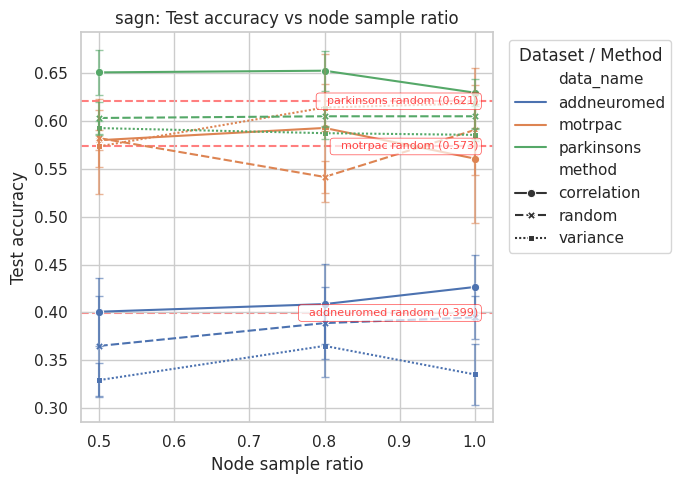

In [7]:
# Make sure ordering is clean and reproducible
dataset_order = ["addneuromed", "motrpac", "parkinsons"]
method_order = ["correlation", "random", "variance"]

for model_name in sorted(agg_df["model_name"].dropna().unique()):
    sub = agg_df[agg_df["model_name"] == model_name].copy()
    if sub.empty:
        continue

    sub = sub.sort_values(["data_name", "method", "node_sample_ratio"])

    plt.figure(figsize=(7, 5))
    
    ax = sns.lineplot(
        data=sub,
        x="node_sample_ratio",
        y="test_acc",
        hue="data_name",        # <-- color = dataset
        style="method",         # <-- line style = method
        markers=True,
        dashes=True,
        hue_order=dataset_order,
        style_order=method_order,
    )

    # Add error bars per (data_name, method)
    for (data_name, method), grp in sub.groupby(["data_name", "method"]):
        ax.errorbar(
            grp["node_sample_ratio"],
            grp["test_acc"],
            yerr=grp["test_acc_std"],
            fmt="none",
            capsize=3,
            alpha=0.6,
            color=sns.color_palette()[dataset_order.index(data_name)],  # match color
        )

    # Add random chance baselines for each dataset
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    for data_name in sub["data_name"].dropna().unique():
        random_chance = random_chance_by_dataset.get(data_name, 0.5)
        ax.axhline(
            y=random_chance,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.5,
            zorder=0,  # Draw behind other elements
        )
        # Add text label
        ax.text(
            xlim[1] * 0.98,
            random_chance,
            f"  {data_name} random ({random_chance:.3f})",
            ha="right",
            va="center",
            fontsize=8,
            color="red",
            alpha=0.7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="red", linewidth=0.5),
        )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(f"{model_name}: Test accuracy vs node sample ratio")
    ax.set_xlabel("Node sample ratio")
    ax.set_ylabel("Test accuracy")
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Dataset / Method"
    )
    plt.tight_layout()
    plt.show()

MODEL PERFORMANCE SUMMARY (sorted by avg performance above chance)
            test_acc_mean  test_acc_std  test_acc_min  test_acc_max  acc_above_chance_mean  acc_above_chance_std  acc_above_chance_min  at_or_below_chance_sum  below_chance_sum  total_experiments  pct_below_chance
model_name                                                                                                                                                                                                           
sage               0.5204        0.1212        0.3393        0.6631                -0.0107                0.0348               -0.0602                      21                21                 27             77.78
gatv2              0.5223        0.1107        0.3393        0.6561                -0.0088                0.0261               -0.0602                      17                17                 27             62.96
gcn                0.5224        0.1098        0.3581        0.6667          

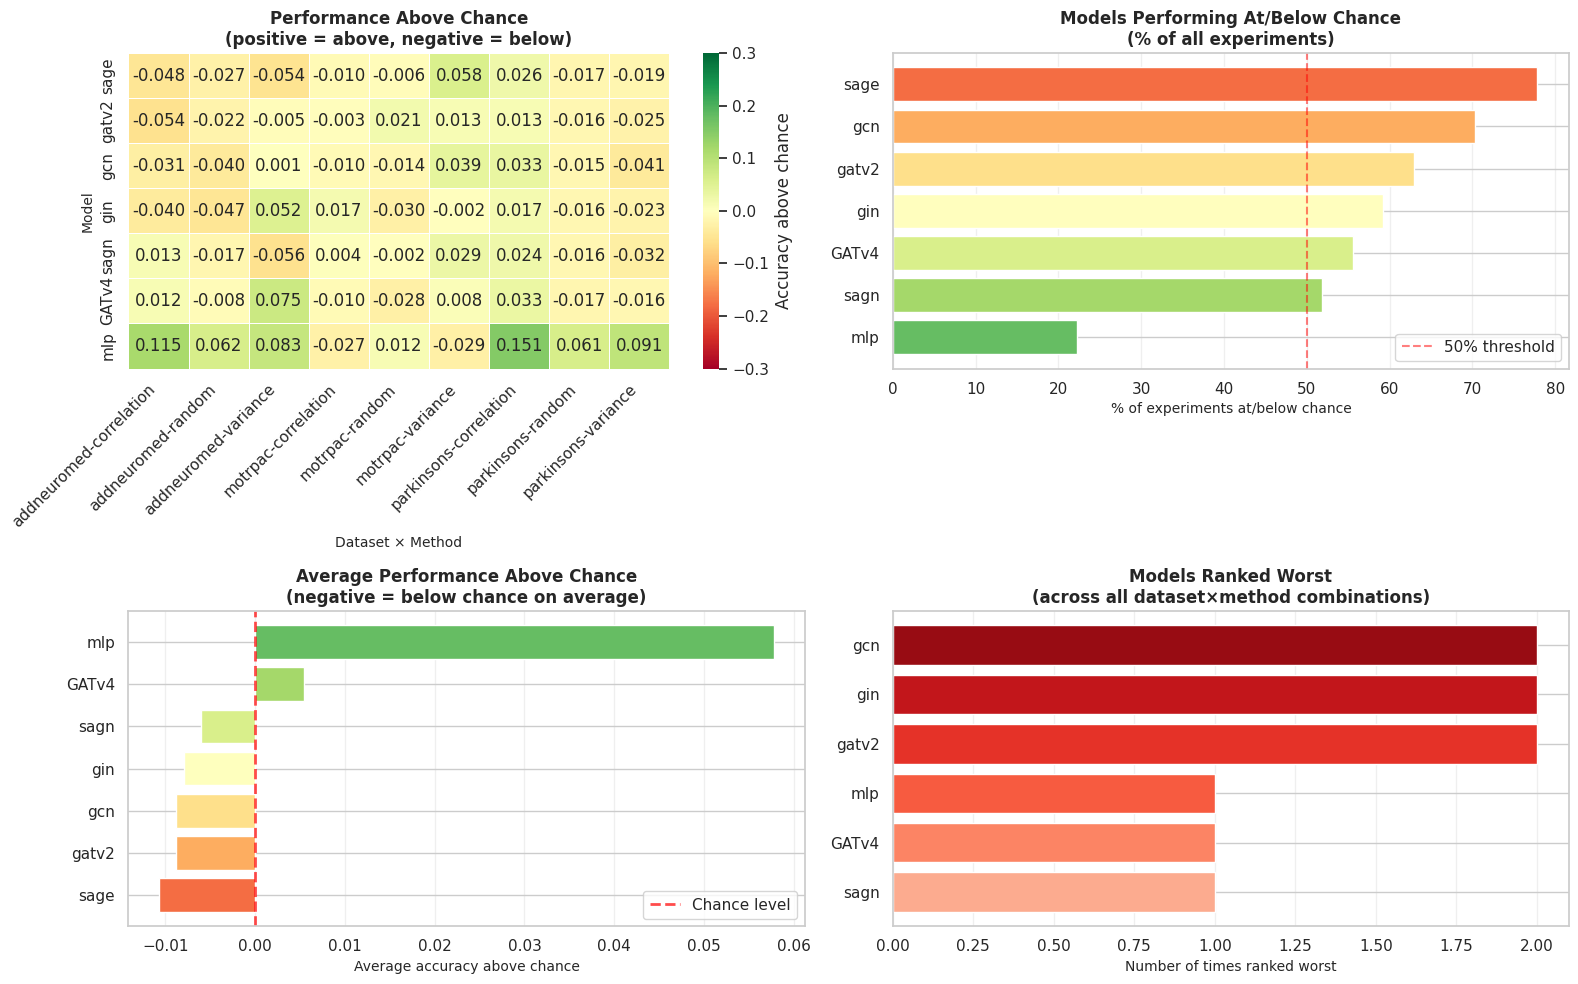


KEY FINDINGS:
Models that perform below chance in >50% of experiments:
  - sage: 77.8% of experiments at/below chance
  - gatv2: 63.0% of experiments at/below chance
  - gcn: 70.4% of experiments at/below chance
  - gin: 59.3% of experiments at/below chance
  - sagn: 51.9% of experiments at/below chance
  - GATv4: 55.6% of experiments at/below chance

Models that rank worst most often:
  - gatv2: worst in 2 dataset×method combinations
  - gin: worst in 2 dataset×method combinations
  - gcn: worst in 2 dataset×method combinations

Models with negative average performance above chance:
  - sage: avg -0.0107 above chance
  - gatv2: avg -0.0088 above chance
  - gcn: avg -0.0088 above chance
  - gin: avg -0.0079 above chance
  - sagn: avg -0.0060 above chance

ANALYSIS BY NODE SAMPLE RATIO

Node sample ratio = 0.5:
  gcn: worst in 3 dataset×method combinations
  gatv2: worst in 2 dataset×method combinations
  GATv4: worst in 2 dataset×method combinations
  sagn: worst in 1 dataset×method c

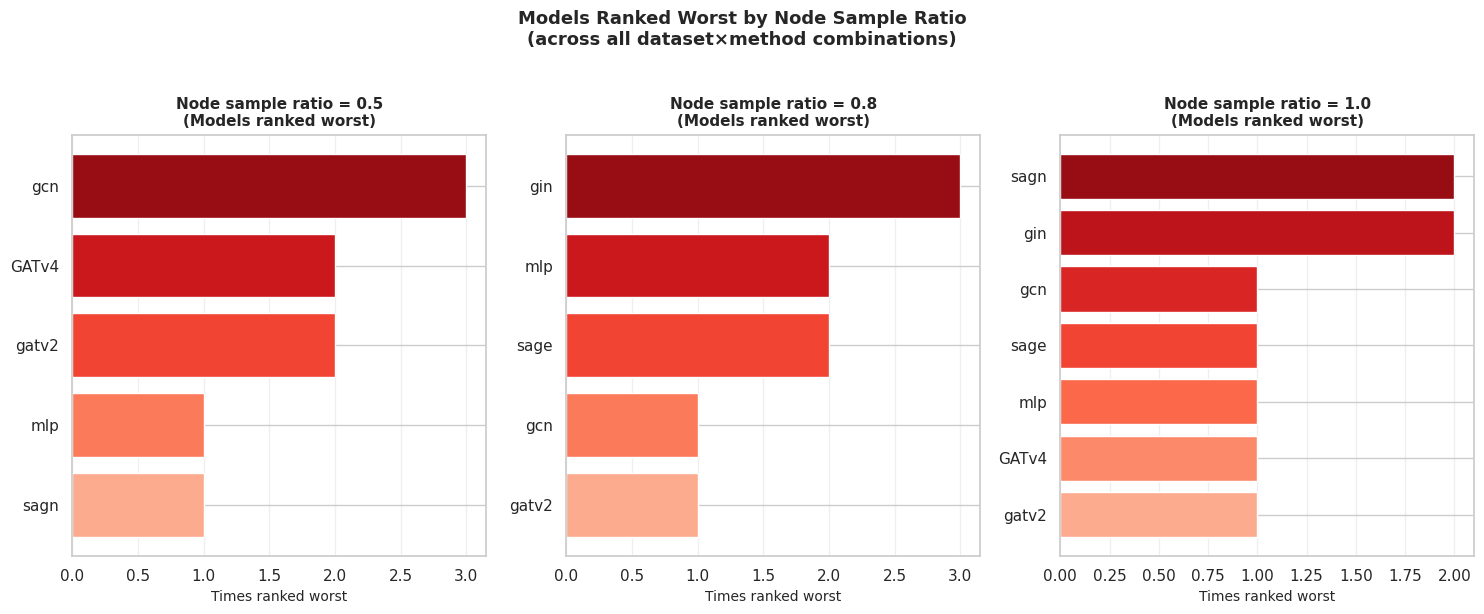

In [10]:
# ============================================================================
# VISUALIZATION: Which models consistently perform worst or at/below chance?
# ============================================================================

# Add random chance baseline to each row
agg_df["random_chance"] = agg_df["data_name"].map(random_chance_by_dataset)
agg_df["above_chance"] = agg_df["test_acc"] > agg_df["random_chance"]
agg_df["below_chance"] = agg_df["test_acc"] < agg_df["random_chance"]
agg_df["at_or_below_chance"] = agg_df["test_acc"] <= agg_df["random_chance"]
agg_df["acc_above_chance"] = agg_df["test_acc"] - agg_df["random_chance"]

# Summary statistics per model (aggregating across ALL node_sample_ratios, datasets, methods)
# Note: This aggregates across node_sample_ratio - each row in agg_df is a unique 
# (model, dataset, method, node_sample_ratio) combination
model_summary = agg_df.groupby("model_name").agg({
    "test_acc": ["mean", "std", "min", "max"],
    "acc_above_chance": ["mean", "std", "min"],
    "at_or_below_chance": "sum",
    "below_chance": "sum",
}).round(4)

# Count total experiments per model
total_experiments = agg_df.groupby("model_name").size()

# Flatten column names first (handle MultiIndex)
if isinstance(model_summary.columns, pd.MultiIndex):
    model_summary.columns = ["_".join(col).strip() if col[1] else col[0] for col in model_summary.columns.values]

model_summary["total_experiments"] = total_experiments

# Calculate percentage below chance
model_summary["pct_below_chance"] = (
    model_summary["at_or_below_chance_sum"] / model_summary["total_experiments"] * 100
).round(2)

model_summary = model_summary.sort_values("acc_above_chance_mean")

print("=" * 80)
print("MODEL PERFORMANCE SUMMARY (sorted by avg performance above chance)")
print("=" * 80)
print(model_summary.to_string())
print("\n")

# Create visualization
fig = plt.figure(figsize=(16, 10))

# 1. Heatmap: Performance relative to chance across datasets and methods
# NOTE: This aggregates (averages) across all node_sample_ratio values
ax1 = plt.subplot(2, 2, 1)
pivot_data = agg_df.pivot_table(
    values="acc_above_chance",
    index="model_name",
    columns=["data_name", "method"],
    aggfunc="mean"  # Averages across all node_sample_ratio values
)
# Sort by average performance
pivot_data = pivot_data.reindex(pivot_data.mean(axis=1).sort_values().index)
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={"label": "Accuracy above chance"},
    ax=ax1,
    linewidths=0.5,
)
ax1.set_title("Performance Above Chance\n(positive = above, negative = below)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Dataset × Method", fontsize=10)
ax1.set_ylabel("Model", fontsize=10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# 2. Bar chart: Percentage of experiments where model performs at/below chance
ax2 = plt.subplot(2, 2, 2)
below_chance_pct = model_summary["pct_below_chance"].sort_values(ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(below_chance_pct)))
bars = ax2.barh(range(len(below_chance_pct)), below_chance_pct.values, color=colors)
ax2.set_yticks(range(len(below_chance_pct)))
ax2.set_yticklabels(below_chance_pct.index)
ax2.set_xlabel("% of experiments at/below chance", fontsize=10)
ax2.set_title("Models Performing At/Below Chance\n(% of all experiments)", fontsize=12, fontweight="bold")
ax2.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50% threshold")
ax2.legend()
ax2.grid(axis="x", alpha=0.3)

# 3. Bar chart: Average performance above chance per model
ax3 = plt.subplot(2, 2, 3)
avg_above_chance = model_summary["acc_above_chance_mean"].sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(avg_above_chance)))
bars = ax3.barh(range(len(avg_above_chance)), avg_above_chance.values, color=colors)
ax3.set_yticks(range(len(avg_above_chance)))
ax3.set_yticklabels(avg_above_chance.index)
ax3.set_xlabel("Average accuracy above chance", fontsize=10)
ax3.set_title("Average Performance Above Chance\n(negative = below chance on average)", fontsize=12, fontweight="bold")
ax3.axvline(x=0, color="red", linestyle="--", linewidth=2, alpha=0.7, label="Chance level")
ax3.legend()
ax3.grid(axis="x", alpha=0.3)

# 4. Count of times each model ranks worst (across dataset×method combinations)
ax4 = plt.subplot(2, 2, 4)
worst_counts = {}
for (data_name, method), group in agg_df.groupby(["data_name", "method"]):
    if len(group) > 0:
        worst_model = group.loc[group["test_acc"].idxmin(), "model_name"]
        worst_counts[worst_model] = worst_counts.get(worst_model, 0) + 1

worst_df = pd.Series(worst_counts).sort_values(ascending=True)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(worst_df)))
bars = ax4.barh(range(len(worst_df)), worst_df.values, color=colors)
ax4.set_yticks(range(len(worst_df)))
ax4.set_yticklabels(worst_df.index)
ax4.set_xlabel("Number of times ranked worst", fontsize=10)
ax4.set_title("Models Ranked Worst\n(across all dataset×method combinations)", fontsize=12, fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print(f"Models that perform below chance in >50% of experiments:")
below_50 = model_summary[model_summary["pct_below_chance"] > 50]
if len(below_50) > 0:
    for model, row in below_50.iterrows():
        print(f"  - {model}: {row['pct_below_chance']:.1f}% of experiments at/below chance")
else:
    print("  None")
    
print(f"\nModels that rank worst most often:")
if len(worst_df) > 0:
    top_worst = worst_df.tail(3)
    for model, count in top_worst.items():
        print(f"  - {model}: worst in {count} dataset×method combinations")
        
print(f"\nModels with negative average performance above chance:")
negative_avg = model_summary[model_summary["acc_above_chance_mean"] < 0]
if len(negative_avg) > 0:
    for model, row in negative_avg.iterrows():
        print(f"  - {model}: avg {row['acc_above_chance_mean']:.4f} above chance")
else:
    print("  None")

# ============================================================================
# ADDITIONAL: Breakdown by node_sample_ratio to see if same models perform worst
# ============================================================================
print("\n" + "=" * 80)
print("ANALYSIS BY NODE SAMPLE RATIO")
print("=" * 80)

# For each node_sample_ratio, see which models perform worst
node_ratios = sorted(agg_df["node_sample_ratio"].dropna().unique())
worst_by_ratio = {}

for ratio in node_ratios:
    sub_df = agg_df[agg_df["node_sample_ratio"] == ratio].copy()
    if sub_df.empty:
        continue
    
    # For each (dataset, method) combination at this ratio, find worst model
    worst_models = []
    for (data_name, method), group in sub_df.groupby(["data_name", "method"]):
        if len(group) > 0:
            worst_model = group.loc[group["test_acc"].idxmin(), "model_name"]
            worst_models.append(worst_model)
    
    # Count how many times each model was worst at this ratio
    from collections import Counter
    worst_counts = Counter(worst_models)
    worst_by_ratio[ratio] = worst_counts
    print(f"\nNode sample ratio = {ratio}:")
    for model, count in worst_counts.most_common():
        print(f"  {model}: worst in {count} dataset×method combinations")

# Create visualization: Which models are worst at each node_sample_ratio?
fig2, axes2 = plt.subplots(1, len(node_ratios), figsize=(5*len(node_ratios), 6))
if len(node_ratios) == 1:
    axes2 = [axes2]

for idx, ratio in enumerate(node_ratios):
    ax = axes2[idx]
    worst_counts = worst_by_ratio.get(ratio, {})
    
    if worst_counts:
        worst_series = pd.Series(worst_counts).sort_values(ascending=True)
        colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(worst_series)))
        bars = ax.barh(range(len(worst_series)), worst_series.values, color=colors)
        ax.set_yticks(range(len(worst_series)))
        ax.set_yticklabels(worst_series.index)
        ax.set_xlabel("Times ranked worst", fontsize=10)
        ax.set_title(f"Node sample ratio = {ratio}\n(Models ranked worst)", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Node sample ratio = {ratio}", fontsize=11)

plt.suptitle("Models Ranked Worst by Node Sample Ratio\n(across all dataset×method combinations)", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
